##**Importar modelo, dataset de test y vocabulario**

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import tensorflow as tf
import os

base_dir = "/content/drive/MyDrive/ESCUELA/IRS/7MO/IA-2/Modulo-2.2/EVIDENCIA/xd"

In [53]:
path = os.path.join(base_dir, 'modelo_xd.keras')
print("Exists?", os.path.exists(path))
print("Full path:", path)

Exists? True
Full path: /content/drive/MyDrive/ESCUELA/IRS/7MO/IA-2/Modulo-2.2/EVIDENCIA/xd/modelo_xd.keras


Vemos que tipo de modelo es el que vamos a usar

In [54]:
model = tf.keras.models.load_model(os.path.join(base_dir,'modelo_xd.keras'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 15, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 15, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,273,285 (16.30 MB)

 Trainable params: 1,424,385 (5.43 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 2,848,772 (10.87 MB)

In [55]:
emb_layer = model.layers[0]  # si la Embedding es la primera capa
print("Embedding input_dim:", emb_layer.input_dim)

Embedding input_dim: 10000


In [56]:
test_dataset = tf.data.Dataset.load(os.path.join(base_dir, "test_dataset"))

In [57]:
for batch_x, batch_y in test_dataset.take(1):
    print("batch_x shape:", batch_x.shape)
    print("min token:", tf.reduce_min(batch_x).numpy())
    print("max token:", tf.reduce_max(batch_x).numpy())

batch_x shape: (128, 15)
min token: 0
max token: 9863


In [58]:
class_names = ["fake_news","real_news"]
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for i, name in enumerate(class_names)}
print(class_to_index)

{'fake_news': 0, 'real_news': 1}


##**Predicciones en dataset de test**

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve)

y_true = np.concatenate([(y.numpy() if hasattr(y, "numpy") else y)for _, y in test_dataset], axis=0)

# Normaliza a vector 1D
if y_true.ndim == 2 and y_true.shape[1] == 1:
    y_true = y_true.ravel()
# Convertir si viene en one-hot
if y_true.ndim == 2 and y_true.shape[1] == 2:
    y_true = np.argmax(y_true, axis=1)

# PREDICCION
y_pred_prob = model.predict(test_dataset).ravel()
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


En un problema binario, la matriz de confusion ayuda a saber

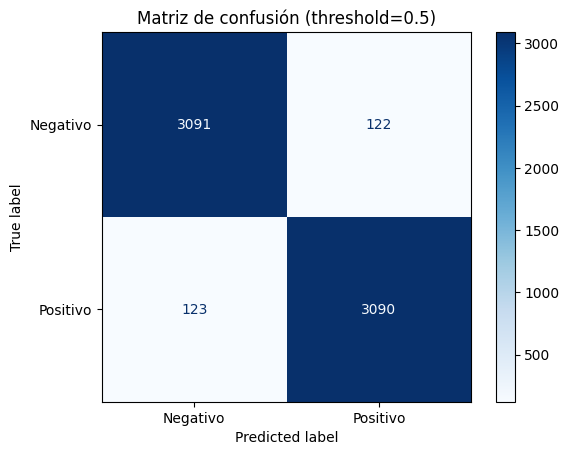

TN=3091 FP=122 FN=123 TP=3090
Accuracy=0.9619  Precision=0.9620  Recall=0.9617  F1=0.9619  ROC-AUC=0.9936

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.96      0.96      0.96      3213
    Positivo       0.96      0.96      0.96      3213

    accuracy                           0.96      6426
   macro avg       0.96      0.96      0.96      6426
weighted avg       0.96      0.96      0.96      6426



In [60]:
# MATRIZ DE CONFUSION
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo","Positivo"])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matriz de confusión (threshold={threshold})")
plt.show()

# METRICAS
tn, fp, fn, tp = cm.ravel()
acc = (tp + tn) / cm.sum()
precision = tp / (tp + fp) if (tp+fp) else 0.0
recall = tp / (tp + fn) if (tp+fn) else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
auc = roc_auc_score(y_true, y_pred_prob)

print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Accuracy={acc:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=['Negativo','Positivo']))

##**Predicciones de texto nuevo**

In [61]:
with open(os.path.join(base_dir,'vocab.txt'), 'r', encoding='utf-8') as f:
    vocab = [line.strip() for line in f if line.strip()]

##**PREDICCIONS**

Funcion para tokenizar: no funciona bien

In [62]:
#from tensorflow.keras.preprocessing.text import Tokenizer

#tokenizer = Tokenizer(num_words=len(vocab))
#tokenizer.word_index = {word: i+1 for i, word in enumerate(vocab)}

In [63]:
#from tensorflow.keras.preprocessing.sequence import pad_sequences
#import numpy as np

#MAX_LEN = 100
#def predict_text(text):
#  seq = tokenizer.texts_to_sequences(text)
#  x = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
#  pred = model.predict(x)
#  print(f"Array: {pred}")
#  preds = (pred >= 0.5).astype(int)
#  print(preds.ravel())

Nueva funcion para vectorizar, checar si funciona

In [64]:
import numpy as np
import string
import re

# Mismo índice que usó TextVectorization:
# vocab[0], vocab[1], ... ya son los tokens en el orden correcto.
word_to_index = {word: i for i, word in enumerate(vocab)}

MAX_LEN = 15          # igual que en etl_xd (MAX_SEQUENCE_LENGTH)
UNK_IDX = 0            # índice para palabras desconocidas
PAD_IDX = 0            # usamos el mismo índice para padding

# Preproceso simple: minúsculas + quitar puntuación + split por espacios
#table = str.maketrans('', '', string.punctuation)

def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

def preprocess(text):
    text = text.lower()
    text = wordopt(text)
    #text = text.translate(table)
    return text.split()

def vectorize_texts(texts):
    sequences = []
    for t in texts:
        tokens = preprocess(t)
        ids = [word_to_index.get(tok, UNK_IDX) for tok in tokens]

        # pad / truncate al largo que vio el modelo en entrenamiento
        if len(ids) < MAX_LEN:
            ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
        else:
            ids = ids[:MAX_LEN]

        sequences.append(ids)

    return np.array(sequences, dtype="int32")

<>:18: SyntaxWarning: invalid escape sequence '\['
<>:22: SyntaxWarning: invalid escape sequence '\w'
<>:18: SyntaxWarning: invalid escape sequence '\['
<>:22: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-3501902878.py:18: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipython-input-3501902878.py:22: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [65]:
def predict_text(texts):
    # texts: lista de strings
    x = vectorize_texts(texts)
    #probs = model.predict(x)
    #preds = (probs >= 0.5).astype("int32")
    # CUARTA VERSION
    threshold = 0.35
    probs = model.predict(x)
    preds = (probs >= threshold).astype(int)

    for t, p, pr in zip(texts, preds, probs):
        label_idx = int(p[0])
        label = class_names[label_idx]
        print("===================================================")
        print("Texto:", t[:200], "...")
        print("Probabilidad real_news:", float(pr[0]))
        print("Predicción:", label)

##FAKE

In [66]:
texts = [
    "Scientists Discover a Second Moon Orbiting Earth Visible Only During Solar Storms"
]
predict_text(texts)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Texto: Scientists Discover a Second Moon Orbiting Earth Visible Only During Solar Storms ...
Probabilidad real_news: 0.998208224773407
Predicción: real_news


In [67]:
sample_text = ["International Space Agency Confirms Humans Can Breathe on Mars for Short Periods"]
predict_text(sample_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Texto: International Space Agency Confirms Humans Can Breathe on Mars for Short Periods ...
Probabilidad real_news: 0.07170963287353516
Predicción: fake_news


In [68]:
texts = [
    "New Study Finds That Plants Communicate Through Invisible Light Beams"
]

predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Texto: New Study Finds That Plants Communicate Through Invisible Light Beams ...
Probabilidad real_news: 0.4182603359222412
Predicción: real_news


In [69]:
texts = [
    "Ocean Floor City Found Intact, Suggesting Ancient Civilization Predated Known History"
]

predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Texto: Ocean Floor City Found Intact, Suggesting Ancient Civilization Predated Known History ...
Probabilidad real_news: 0.8748376369476318
Predicción: real_news


In [70]:
texts = [
    "Researchers Develop Technology That Allows People to Upload Dreams to a Computer"
]

predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Texto: Researchers Develop Technology That Allows People to Upload Dreams to a Computer ...
Probabilidad real_news: 0.9135086536407471
Predicción: real_news


In [71]:
texts = [
    "A new study claims that drinking two cups of coffee before bed can improve sleep quality and memory retention. Researchers allegedly found that caffeine helps the brain relax and promotes deeper rest phases during the night."
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Texto: A new study claims that drinking two cups of coffee before bed can improve sleep quality and memory retention. Researchers allegedly found that caffeine helps the brain relax and promotes deeper rest  ...
Probabilidad real_news: 0.020539458841085434
Predicción: fake_news


In [72]:
texts = [
    "Google announced it has developed a chip that can directly translate human thoughts into text messages without using a phone or computer. The company says the device will be available next year."
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Texto: Google announced it has developed a chip that can directly translate human thoughts into text messages without using a phone or computer. The company says the device will be available next year. ...
Probabilidad real_news: 0.001370376325212419
Predicción: fake_news


In [73]:
texts = [
    "president trump and president putin decide to settle ukranian dispute by playing a game of checkers"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Texto: president trump and president putin decide to settle ukranian dispute by playing a game of checkers ...
Probabilidad real_news: 0.5416925549507141
Predicción: real_news


##REAL

In [74]:
texts = [
    "UN Warns That Global Temperatures Are on Track to Break Records Again in 2025"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Texto: UN Warns That Global Temperatures Are on Track to Break Records Again in 2025 ...
Probabilidad real_news: 0.963154673576355
Predicción: real_news


In [75]:
texts = [
    "NASA Successfully Deploys New Earth-Observing Satellite to Monitor Climate Patterns"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Texto: NASA Successfully Deploys New Earth-Observing Satellite to Monitor Climate Patterns ...
Probabilidad real_news: 0.31995001435279846
Predicción: fake_news


In [76]:
texts = [
    "World Health Organization Launches Initiative to Expand Access to Mental Health Services"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Texto: World Health Organization Launches Initiative to Expand Access to Mental Health Services ...
Probabilidad real_news: 0.3990611433982849
Predicción: real_news


In [77]:
texts = [
    "Major Economies Agree on Framework to Reduce Plastic Pollution by 2040"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Texto: Major Economies Agree on Framework to Reduce Plastic Pollution by 2040 ...
Probabilidad real_news: 0.9684622883796692
Predicción: real_news


In [78]:
texts = [
    "Breakthrough in Battery Technology Promises Longer Range for Electric Vehicles"
]
predict_text(texts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Texto: Breakthrough in Battery Technology Promises Longer Range for Electric Vehicles ...
Probabilidad real_news: 0.9169876575469971
Predicción: real_news


##BLOQUE

In [79]:
import pandas as pd

def predict_block(texts):
    x = vectorize_texts(texts)
    raw_probs = model.predict(x)
    full_probs = np.hstack([1 - raw_probs, raw_probs])

    df = pd.DataFrame(full_probs, columns=class_names)
    df.insert(0, "title", texts)

    pred_idx = np.argmax(full_probs, axis=1)
    pred_label = [index_to_class[i] for i in pred_idx]

    confidence = full_probs[np.arange(len(full_probs)), pred_idx]
    df["predicted"] = pred_label
    df["confidence"] = confidence

    return df

In [80]:
texts = [
    # REAL NEWS
    "James Webb Telescope Detects Organic Molecules in a Distant Planet’s Atmosphere",
    "WHO Reports Sharp Decline in Global Measles Vaccinations After Pandemic Disruptions",
    "Researchers Develop Biodegradable Plastic That Breaks Down in Ocean Water Within Weeks",
    "Study Finds That Mediterranean Diet Significantly Reduces Risk of Heart Disease",
    "Major Tech Companies Announce Partnership to Standardize AI Safety Testing",

    # FAKE NEWS
    "Archaeologists Discover 10,000-Year-Old Stone Tablet Describing an Ancient Solar Eclipse",
    "Japanese Scientists Report Breakthrough That Allows Trees to Glow Naturally at Night",
    "New Medical Device Claims to Heal Bone Fractures in Minutes Without Surgery",
    "Researchers Confirm Dolphins Can Recognize Themselves in Photographs Like Humans",
    "Study Suggests That Listening to Certain Frequencies Can Temporarily Improve Night Vision"

]

In [81]:
df_predicted = predict_block(texts)
df_predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


,title,fake_news,real_news,predicted,confidence
0,James Webb Telescope Detects Organic Molecules...,0.028183,0.971817,real_news,0.971817
1,WHO Reports Sharp Decline in Global Measles Va...,0.051780,0.948220,real_news,0.948220
2,Researchers Develop Biodegradable Plastic That...,0.148116,0.851884,real_news,0.851884
3,Study Finds That Mediterranean Diet Significan...,0.004233,0.995767,real_news,0.995767
4,Major Tech Companies Announce Partnership to S...,0.062349,0.937651,real_news,0.937651
5,"Archaeologists Discover 10,000-Year-Old Stone ...",0.032768,0.967232,real_news,0.967232
6,Japanese Scientists Report Breakthrough That A...,0.831316,0.168684,fake_news,0.831316
7,New Medical Device Claims to Heal Bone Fractur...,0.079991,0.920009,real_news,0.920009
8,Researchers Confirm Dolphins Can Recognize The...,0.933963,0.066037,fake_news,0.933963
9,Study Suggests That Listening to Certain Frequ...,0.914122,0.085878,fake_news,0.914122


In [82]:
more_texts = [
    # REAL NEWS
    "Global Coral Reefs Show Early Signs of Recovery After Large-Scale Restoration Efforts",
    "New Alzheimer’s Drug Demonstrates Promising Results in Late-Stage Clinical Trials",
    "International Team Successfully Maps the Deepest Known Point of the Atlantic Ocean",
    "Breakthrough Robotic Exoskeleton Helps Paralyzed Patients Walk Independently",
    "UNESCO Adds Ancient Cave Art Site to the World Heritage List",
    "Scientists Identify New Species of Orchid in the Amazon Rainforest",
    "Researchers Develop Solar Panel That Can Generate Power During Rainfall",
    "Major Study Finds That Teen Sleep Deprivation Is Linked to Lower Academic Performance",
    "New Electric Air Taxi Completes First Successful Test Flight Over Urban Area",
    "Breakthrough in Quantum Computing Achieves Record Stability in Qubit Operations",

    # FAKE NEWS
    "Fox News Exposes Traitor Megyn Kelly, Kicks Her Out For Backing Hillary",
    "NBC just fired Megyn Kelly before her new show begins",
    "Net Hoax Convinces Germany of Fake U.S. Suicide Bombing Attempt",
    "FBI Created Fake News Article With Spyware to Track Suspect",
    "Fake Kamala hit-and-run story is the work of Russian propaganda group",
    "Pope Francis Shocks World, Endorses Donald Trump for President",
    "ISIS Leader Calls for Voters to Support Hillary Clinton",
    "FBI Agent Suspected in Hillary Email Leaks Found Dead in Apparent Murder-Suicide",
    "CDC Confirms That Vaccinated Children Are 300% More Likely to Develop Autism",
    "Engineers Create Self-Heating Backpacks That Keep Food Warm for 24 Hours Without Batteries"

]

In [83]:
df_predicted = predict_block(more_texts)
df_predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


,title,fake_news,real_news,predicted,confidence
0,Global Coral Reefs Show Early Signs of Recover...,0.002361,0.997639,real_news,0.997639
1,New Alzheimer’s Drug Demonstrates Promising Re...,0.683234,0.316766,fake_news,0.683234
2,International Team Successfully Maps the Deepe...,0.174381,0.825619,real_news,0.825619
3,Breakthrough Robotic Exoskeleton Helps Paralyz...,0.009775,0.990225,real_news,0.990225
4,UNESCO Adds Ancient Cave Art Site to the World...,0.953662,0.046338,fake_news,0.953662
5,Scientists Identify New Species of Orchid in t...,0.162829,0.837171,real_news,0.837171
6,Researchers Develop Solar Panel That Can Gener...,0.185235,0.814765,real_news,0.814765
7,Major Study Finds That Teen Sleep Deprivation ...,0.853315,0.146685,fake_news,0.853315
8,New Electric Air Taxi Completes First Successf...,0.982940,0.017060,fake_news,0.982940
9,Breakthrough in Quantum Computing Achieves Rec...,0.020930,0.979070,real_news,0.979070
